In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
# Load the dataset
dataset = pd.read_csv('nba_preprocessed.csv')
dataset.head()


,Game_Date,Team,Player,MP,PTS,TRB,AST,FGA,FG%,STL,TOV
0,20251101,25,113,1.830533,2.048740,-0.015845,0.208047,1.805808,0.293646,-0.78218,0.508793
1,20251101,25,494,1.582544,2.273030,-0.015845,-0.177476,1.470112,0.059664,0.22981,-0.910007
2,20251101,25,117,1.418808,1.488015,0.283463,1.750142,0.798719,0.672273,1.24180,1.218193
3,20251101,25,127,1.404501,1.488015,2.677930,1.364618,0.798719,0.672273,0.22981,1.218193
4,20251101,25,143,-1.636546,-0.979176,-0.913770,-0.948523,-1.215461,2.310152,-0.78218,-0.910007


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features and target
X = dataset.drop('PTS', axis=1)
y = dataset['PTS']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the Multiple Linear Regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)


LinearRegression()

In [4]:
# Predict the Test set results
y_pred = regressor.predict(X_test)
# Display some predictions vs actual values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)

        Actual  Predicted
2678  2.273030   1.223813
3625 -0.642740  -0.819295
4202 -0.194160  -0.004504
1373  1.151580   1.019131
5422  0.478710   0.745904
...        ...        ...
7201  1.936595   1.270223
576   0.815145   0.621085
3146 -0.194160  -0.006286
5933 -0.194160   0.511740
1775 -0.418450   0.077645

[1814 rows x 2 columns]



R-squared (Accuracy): 0.8730
Root Mean Squared Error: 0.3528


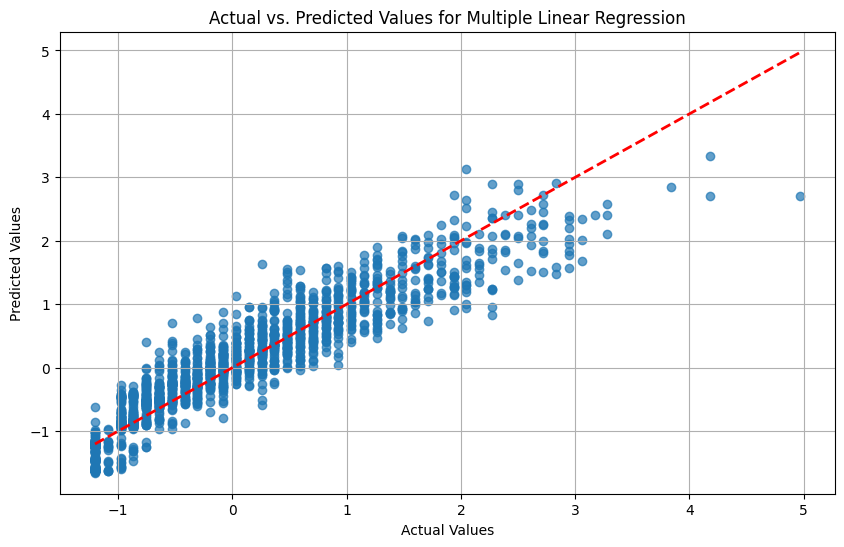

In [5]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR-squared (Accuracy): {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Multiple Linear Regression')
plt.grid(True)
plt.show()

In [6]:
# Let's check the number of matches per player
# First, I need to identify the player and date columns.
print(dataset.info())
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9067 entries, 0 to 9066
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Game_Date  9067 non-null   int64  
 1   Team       9067 non-null   int64  
 2   Player     9067 non-null   int64  
 3   MP         9067 non-null   float64
 4   PTS        9067 non-null   float64
 5   TRB        9067 non-null   float64
 6   AST        9067 non-null   float64
 7   FGA        9067 non-null   float64
 8   FG%        9067 non-null   float64
 9   STL        9067 non-null   float64
 10  TOV        9067 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 779.3 KB
None
   Game_Date  Team  Player        MP       PTS       TRB       AST       FGA  \
0   20251101    25     113  1.830533  2.048740 -0.015845  0.208047  1.805808   
1   20251101    25     494  1.582544  2.273030 -0.015845 -0.177476  1.470112   
2   20251101    25     117  1.418808  1.488015  0.283463  1.750142  0.798719